device: cuda
NCA ready – 52 channels
Target shape: torch.Size([1, 4, 32, 32, 32])


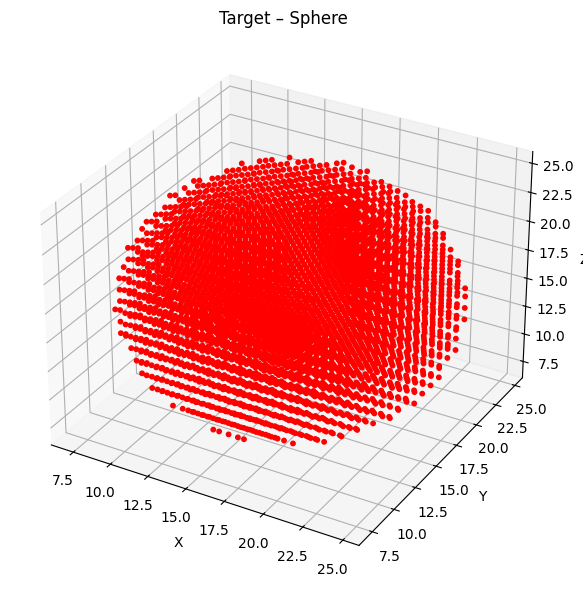

   0 | loss 0.063609


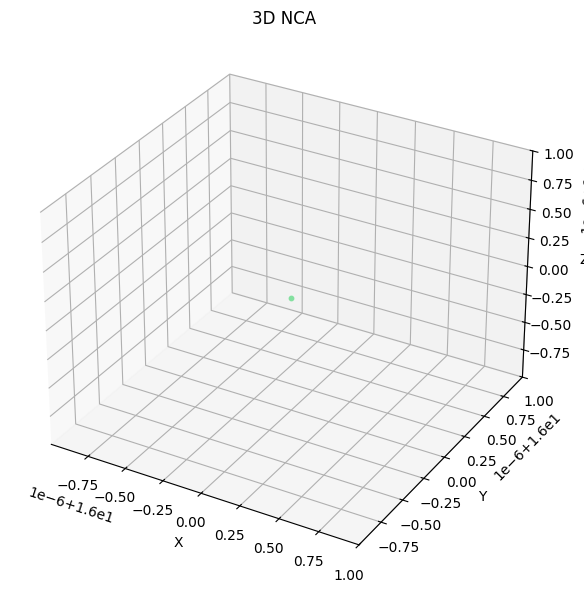

  50 | loss 0.063678
nothing alive
 100 | loss 0.063678
nothing alive
 150 | loss 0.063678
nothing alive
 200 | loss 0.063678
nothing alive
 250 | loss 0.063678
nothing alive
 300 | loss 0.063678
nothing alive
 350 | loss 0.063678
nothing alive


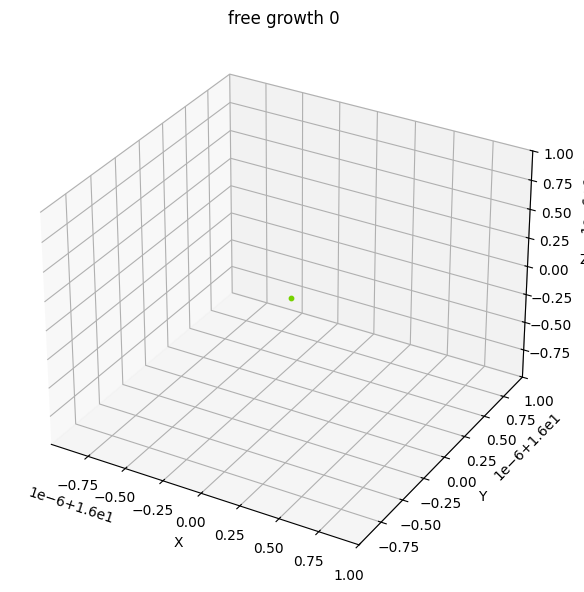

nothing alive
nothing alive
nothing alive
nothing alive
DONE


In [ ]:
import torch, torch.nn.functional as F, matplotlib.pyplot as plt, numpy as np
from pathlib import Path, sys

try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
project_root = script_dir.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from core.perception import PerceptionConfig
from core.cell import CellConfig
from core.update import UpdateConfig
from core.grid import GridConfig, Grid3D

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

perc_cfg = PerceptionConfig(kernel_radius=1, channel_groups=3)
cell_cfg = CellConfig(hidden_channels=48, visible_channels=4, alive_threshold=0.1)
upd_cfg  = UpdateConfig(hidden_dim=128, stochastic_update=True, fire_rate=0.5)
grid_cfg = GridConfig(size=(32,32,32))

nca = Grid3D(cell_cfg=cell_cfg, perc_cfg=perc_cfg,
             upd_cfg=upd_cfg, grid_cfg=grid_cfg).to(device)
print(f"NCA ready – {nca.cell.total_channels} channels")

def sphere_target(radius=10):
    sz = grid_cfg.size
    c = torch.tensor(sz, dtype=torch.float32)//2
    x,y,z = torch.meshgrid(torch.arange(sz[0]), torch.arange(sz[1]), torch.arange(sz[2]), indexing='ij')
    mask = (x-c[0])**2 + (y-c[1])**2 + (z-c[2])**2 <= radius**2
    t = torch.zeros(1, cell_cfg.visible_channels, *sz, device=device)
    t[0,0,mask] = 1.0
    t[0,3,mask] = 1.0
    return t
target = sphere_target()
print(f"Target shape: {target.shape}")

def plot_voxel(state_tensor, threshold=0.1, title="3D NCA", max_points=5000):
    if state_tensor.dim() == 2:
        raise ValueError("plot_voxel got 2‑D tensor")
    if state_tensor.dim() == 4:
        state_tensor = state_tensor.unsqueeze(0)

    visible = state_tensor[:, -4:, ...]
    alpha   = visible[:, 3, ...]
    rgb     = visible[:, :3, ...]

    mask = alpha > threshold
    if not mask.any():
        print("nothing alive")
        return

    b_idx, x, y, z = torch.where(mask)
    colors = rgb[b_idx, :, x, y, z].cpu().numpy()
    coords = torch.stack([x, y, z], dim=1).cpu().numpy()

    if len(coords) > max_points:
        sel = np.random.choice(len(coords), max_points, replace=False)
        coords, colors = coords[sel], colors[sel]

    colors = colors.reshape(-1, 3)
    colors = np.clip(colors, 0.0, 1.0)

    fig = plt.figure(figsize=(8,6))
    ax  = fig.add_subplot(111, projection='3d')
    ax.scatter(coords[:,0], coords[:,1], coords[:,2],
               c=colors, s=10, depthshade=False)

    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)

    r = np.ptp(coords, axis=0).max() / 2.0
    m = np.mean(coords, axis=0)
    eps = 1e-6
    ax.set_xlim(m[0]-max(r, eps), m[0]+max(r, eps))
    ax.set_ylim(m[1]-max(r, eps), m[1]+max(r, eps))
    ax.set_zlim(m[2]-max(r, eps), m[2]+max(r, eps))

    plt.tight_layout()
    plt.show()

plot_voxel(target, title="Target – Sphere")

opt = torch.optim.Adam(nca.parameters(), lr=1e-3)

def step(state, steps=8):
    state = nca(state, steps)
    loss = F.mse_loss(state[:, -cell_cfg.visible_channels:,...], target)
    return state.detach(), loss

nca.train()
state = nca.seed_center(batch_size=1, device=device).clone().requires_grad_(True)

for it in range(400):
    opt.zero_grad()
    state, loss = step(state)
    loss.backward()
    opt.step()

    state = state.clone().requires_grad_(True)

    if it % 50 == 0:
        print(f"{it:4d} | loss {loss.item():.6f}")
        with torch.no_grad():
            plot_voxel(state.detach())

with torch.no_grad():
    s = nca.seed_center(1, device)
    for i in range(200):
        s = nca.step(s)
        if i % 40 == 0:
            plot_voxel(s, title=f"free growth {i}")
print("DONE")